# Visualizar os dados tratados

In [3]:
import math
import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from spellchecker import SpellChecker
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler

# Downloads do NLTK (executa apenas uma vez)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True) 

# ==========================================
# 1. CLASSE EXTRATORA DE FEATURES (OTIMIZADA)
# ==========================================
class TextFeatureExtractor:
    def __init__(self, max_vocab=1500):
        self.max_vocab = max_vocab
        self.spell = SpellChecker()
        self.vocab = None
        self.vocab_set = None
        self.idf = None
        
        # Tracking GLTR
        self.unigram_counts = Counter()
        self.bigram_counts = Counter()
        self.bigram_ranks = {}
        
        self.stopwords = set(stopwords.words("english"))
        self.LLM_BUZZWORDS = {
            'furthermore','moreover','delve','tapestry',
            'testament','pivotal','underscore','multifaceted',
            'crucial','consequently'
        }
        self.FUNCTION_WORDS = {
            'the','of','to','and','a','in','that','is','it','for','on','with',
            'as','at','this','by','from','or','an','be','are','was','were'
        }

    def _get_gltr_metrics(self, words):
        """Calcula a distribuição de GLTR (Top 10, Top 100, etc.) em tempo O(1)"""
        if len(words) < 2 or not self.bigram_ranks:
            return 0, 0, 0, 0
            
        bigrams = list(zip(words, words[1:]))
        top_10 = top_100 = top_1000 = rest = 0
        
        for w1, w2 in bigrams:
            # Procura instantânea do ranking!
            rank = self.bigram_ranks.get((w1, w2), None)
            
            if rank is None:
                rest += 1
            elif rank <= 10:
                top_10 += 1
            elif rank <= 100:
                top_100 += 1
            elif rank <= 1000:
                top_1000 += 1
            else:
                rest += 1
                
        total = len(bigrams)
        return top_10/total, top_100/total, top_1000/total, rest/total

    def _get_metrics(self, text):
        sentences = sent_tokenize(text)
        raw_tokens = word_tokenize(text)
        words = [w.lower() for w in raw_tokens if w.isalpha()]
    
        if not words:
            return [0] * 24 # 16 originais + 8 novas
    
        # ---------- BASIC FEATURES ----------
        s_lengths = [len(word_tokenize(s)) for s in sentences]
        burst = np.std(s_lengths) if len(sentences) > 1 else 0
        typos = len(self.spell.unknown(words)) / len(words)
        counts = Counter(words)
        total = len(words)
        ent = sum(-(c/total)*math.log2(c/total) for c in counts.values())
        ttr_val = len(set(words))/len(words)
        awl = np.mean([len(w) for w in words])
        asl = len(words)/len(sentences) if sentences else 0
        buzz = sum(w in self.LLM_BUZZWORDS for w in words)/len(words)
        
        tags = nltk.pos_tag(raw_tokens)
        adj = sum(tag.startswith('JJ') for _,tag in tags)/len(raw_tokens) if raw_tokens else 0
        punct = (text.count('!') + text.count('?') + text.count('...')) / len(text) if text else 0
    
        # ---------- NGRAM FEATURES ----------
        bigrams = list(zip(words, words[1:]))
        unique_bigrams = len(set(bigrams))
        bigram_ratio = unique_bigrams / len(bigrams) if bigrams else 0
        text_clean = text.replace(" ", "_")
        char_trigrams = [text_clean[i:i+3] for i in range(len(text_clean)-2)]
        char_trigram_density = len(set(char_trigrams)) / len(char_trigrams) if char_trigrams else 0
    
        # ---------- PERPLEXITY ----------
        unigram_counts = Counter(words)
        bigram_counts = Counter(bigrams)
        log_prob_sum = 0
        N = len(bigrams)
        for w1, w2 in bigrams:
            p = (bigram_counts[(w1,w2)] + 1) / (unigram_counts[w1] + len(unigram_counts))
            log_prob_sum += math.log2(p)
        perplexity = 2 ** (-log_prob_sum / N) if N > 0 else 0
    
        # ---------- POS FEATURES ----------
        pos_tags = [tag for _,tag in tags]
        pos_counts = Counter(pos_tags)
        pos_total = len(pos_tags)
        pos_entropy = sum(-(c/pos_total)*math.log2(c/pos_total) for c in pos_counts.values())
    
        # ---------- RHYTHM, STOPWORD E RARE WORD ----------
        rhythm_var = np.var(s_lengths) if len(s_lengths) > 1 else 0
        stop_ratio = sum(w in self.stopwords for w in words)/len(words)
        rare_words = [w for w,c in counts.items() if c == 1]
        rare_ratio = len(rare_words)/len(words)
        
        # ==========================================
        # ---------- AS 8 NOVAS FEATURES -----------
        # ==========================================
        
        # 1. Function Word Ratio & Entropy
        fw = [w for w in words if w in self.FUNCTION_WORDS]
        fw_ratio = len(fw) / len(words)
        if fw:
            fw_counts = Counter(fw)
            fw_total = len(fw)
            fw_entropy = sum(-(c/fw_total)*math.log2(c/fw_total) for c in fw_counts.values())
        else:
            fw_entropy = 0
            
        # 2. Repetition Distance
        last_seen = {}
        distances = []
        for i, w in enumerate(words):
            if w in last_seen:
                distances.append(i - last_seen[w])
            last_seen[w] = i
        rep_distance = np.mean(distances) if distances else 0
        
        # 3. Sentence Length Entropy
        if s_lengths:
            sl_counts = Counter(s_lengths)
            sl_total = len(s_lengths)
            sl_entropy = sum(-(c/sl_total)*math.log2(c/sl_total) for c in sl_counts.values())
        else:
            sl_entropy = 0
            
        # 4. GLTR Approach
        gltr_top10, gltr_top100, gltr_top1000, gltr_rest = self._get_gltr_metrics(words)
    
        return [
            burst, typos, ent, ttr_val, awl, asl, buzz, adj, punct,
            bigram_ratio, char_trigram_density, perplexity, pos_entropy,
            rhythm_var, stop_ratio, rare_ratio,
            fw_ratio, fw_entropy, rep_distance, sl_entropy,
            gltr_top10, gltr_top100, gltr_top1000, gltr_rest
        ]

    def fit_tfidf(self, corpus):
        tokenized = [re.findall(r'\b[a-zA-Z]+\b', doc.lower()) for doc in corpus]
        doc_freq = Counter()
        
        for doc in tokenized:
            for word in set(doc):
                doc_freq[word] += 1
            
            # Tracking GLTR
            self.unigram_counts.update(doc)
            self.bigram_counts.update(zip(doc, doc[1:]))
            
        self.vocab = [w for w, _ in doc_freq.most_common(self.max_vocab)]
        self.vocab_set = set(self.vocab)
        N = len(corpus)
        self.idf = {w: math.log((1+N)/(1+doc_freq[w])) + 1 for w in self.vocab}
        
        # --- PRÉ-COMPUTAÇÃO GLTR (A Magia da Velocidade) ---
        following_dict = defaultdict(list)
        for (w1, w2), count in self.bigram_counts.items():
            following_dict[w1].append((w2, count))
            
        self.bigram_ranks = {}
        for w1, following in following_dict.items():
            following.sort(key=lambda x: x[1], reverse=True) 
            for rank, (w2, count) in enumerate(following):
                self.bigram_ranks[(w1, w2)] = rank + 1

    def transform_tfidf(self, corpus):
        matrix = []
        for doc in corpus:
            words = re.findall(r'\b[a-zA-Z]+\b', doc.lower())
            tf = Counter(words)
            length = len(words) if words else 1
            row = [(tf.get(w, 0)/length) * self.idf[w] for w in self.vocab]
            matrix.append(row)
        return np.array(matrix)

    def fit_transform(self, corpus):
        corpus = [str(t) for t in corpus]
        self.fit_tfidf(corpus)
        tfidf_matrix = self.transform_tfidf(corpus)
        behavioral_matrix = np.array([self._get_metrics(t) for t in corpus])
        return tfidf_matrix, behavioral_matrix

# ==========================================
# 2. PREPARAÇÃO DO DATASET
# ==========================================

# Substitui o caminho pelo teu ficheiro real
df = pd.read_csv("../data/dataset.csv").dropna()

extractor = TextFeatureExtractor(max_vocab=1500)
print("A extrair TF-IDF e as 24 Métricas Comportamentais (Otimizado!)...")
X_tfidf, X_extra = extractor.fit_transform(df["text"])

# Normalização (StandardScaler)
scaler_comportamental = StandardScaler()
X_extra_norm = scaler_comportamental.fit_transform(X_extra)

# Concatenar (1500 TF-IDF + 24 métricas = 1524 inputs)
X_combined = np.hstack((X_tfidf, X_extra_norm))

# One-Hot Encoding das Labels (Para a rede NumPy)
labels_list = df['label'].unique()
label_to_idx = {l: i for i, l in enumerate(labels_list)}
Y_indices = np.array([label_to_idx[l] for l in df['label']])
Y_onehot = np.zeros((len(Y_indices), len(labels_list)))
Y_onehot[np.arange(len(Y_indices)), Y_indices] = 1

# Split (70% Treino, 10% Validação, 20% Teste)
np.random.seed(42)
shuffled_idx = np.arange(len(X_combined))
np.random.shuffle(shuffled_idx)

X_s, Y_s = X_combined[shuffled_idx], Y_onehot[shuffled_idx]

train_end = int(len(X_s) * 0.7)
val_end = int(len(X_s) * 0.8)

X_train, Y_train = X_s[:train_end], Y_s[:train_end]
X_val, Y_val     = X_s[train_end:val_end], Y_s[train_end:val_end]
X_test, Y_test   = X_s[val_end:], Y_s[val_end:]

print(f"Dataset processado: {X_train.shape[0]} treino, {X_val.shape[0]} validação, {X_test.shape[0]} teste.")
print(f"Dimensão final do input da rede: {X_train.shape[1]}")

A extrair TF-IDF e as 24 Métricas Comportamentais (Otimizado!)...
Dataset processado: 1722 treino, 246 validação, 492 teste.
Dimensão final do input da rede: 1524


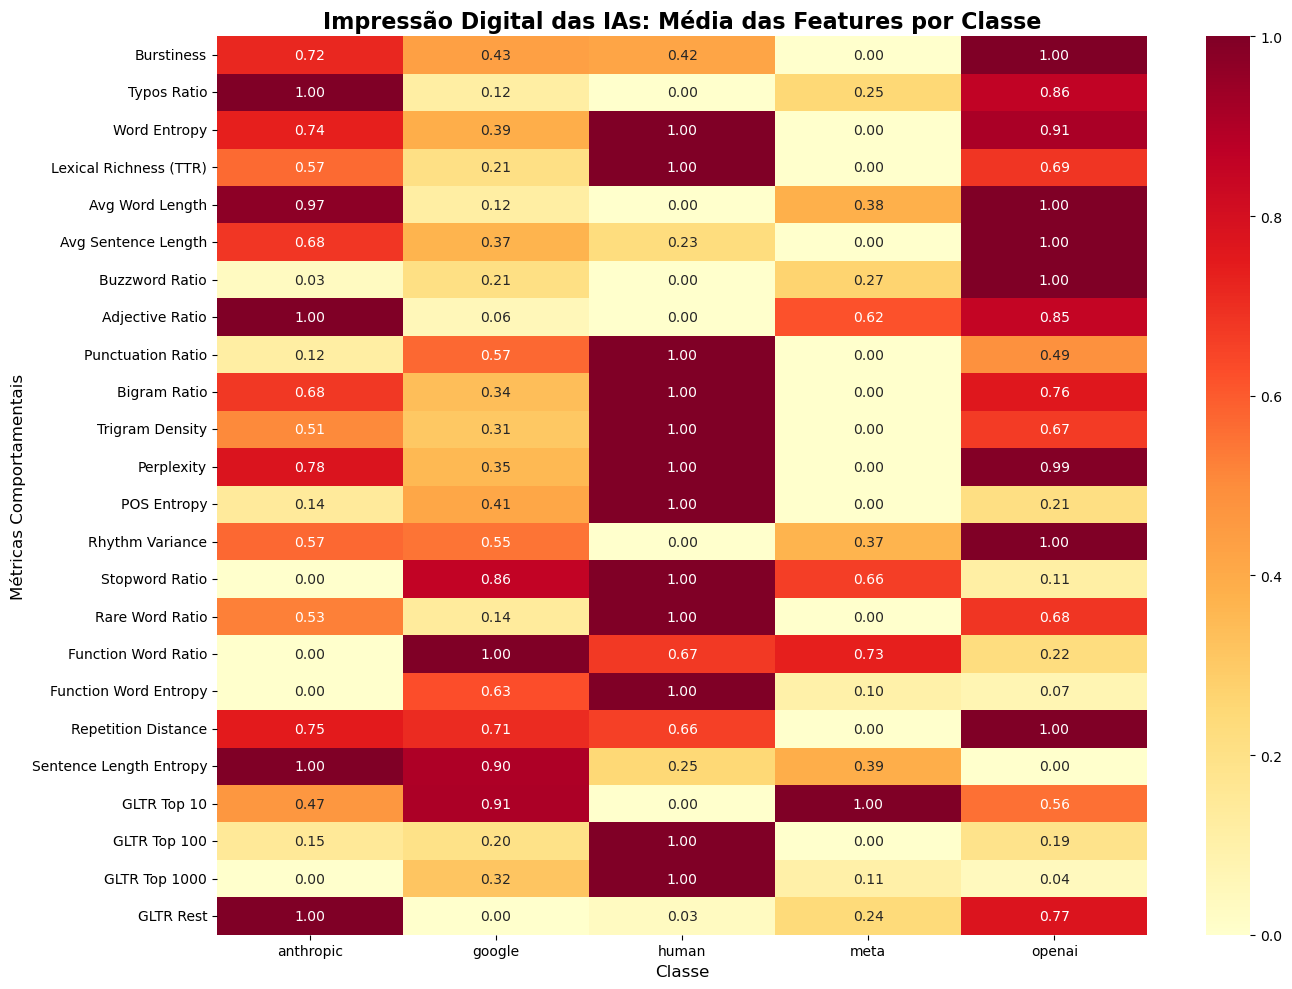

C:\Users\mjurb\AppData\Local\Temp\ipykernel_23028\3827814311.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classe', y=feature, data=df_visual, ax=axes[i], palette='pastel')
C:\Users\mjurb\AppData\Local\Temp\ipykernel_23028\3827814311.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classe', y=feature, data=df_visual, ax=axes[i], palette='pastel')
C:\Users\mjurb\AppData\Local\Temp\ipykernel_23028\3827814311.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Classe', y=feature, data=df_visual, ax=axes[i], palette='pastel'

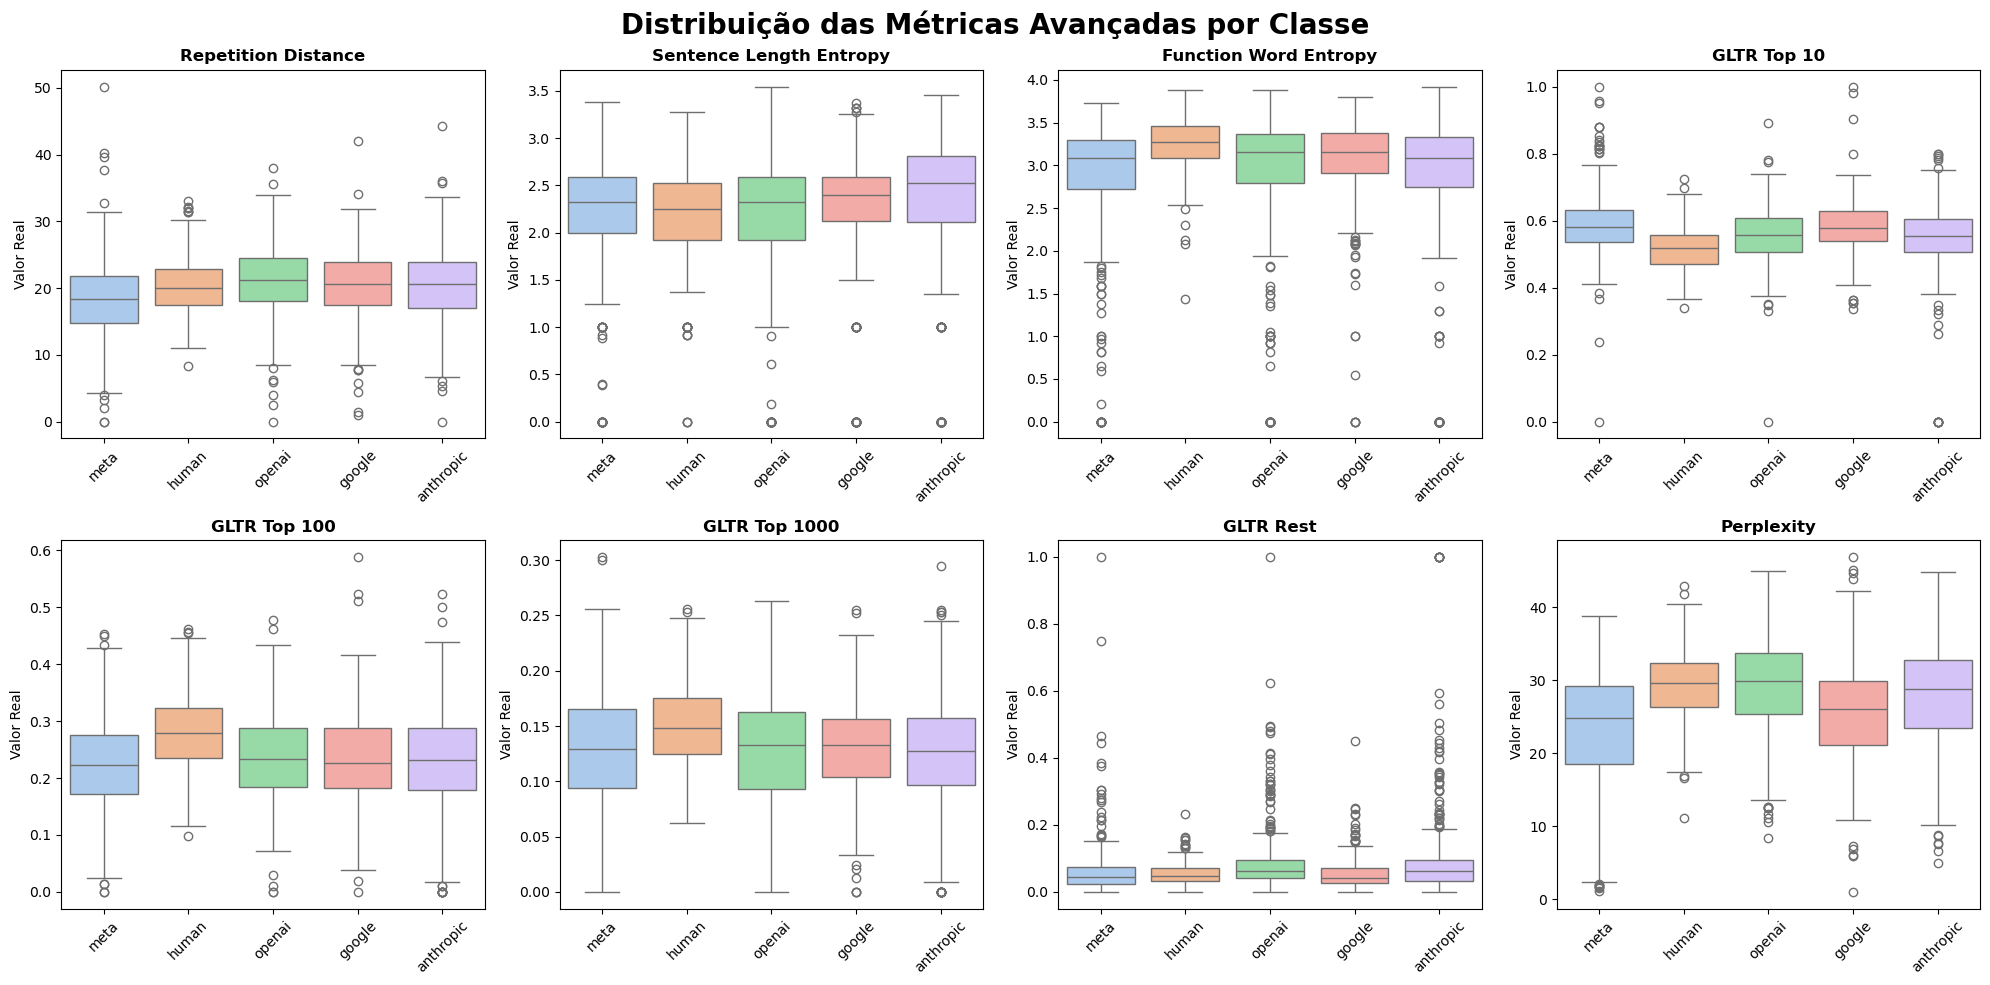

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definir os nomes exatos das 24 métricas pela ordem que estão no teu return
feature_names = [
    'Burstiness', 'Typos Ratio', 'Word Entropy', 'Lexical Richness (TTR)', 
    'Avg Word Length', 'Avg Sentence Length', 'Buzzword Ratio', 'Adjective Ratio', 'Punctuation Ratio',
    'Bigram Ratio', 'Trigram Density', 'Perplexity', 'POS Entropy',
    'Rhythm Variance', 'Stopword Ratio', 'Rare Word Ratio',
    # As 8 Novas:
    'Function Word Ratio', 'Function Word Entropy', 'Repetition Distance', 'Sentence Length Entropy',
    'GLTR Top 10', 'GLTR Top 100', 'GLTR Top 1000', 'GLTR Rest'
]

# 2. Criar um DataFrame com os valores REAIS (X_extra)
df_visual = pd.DataFrame(X_extra, columns=feature_names)
df_visual['Classe'] = df['label'].values

# ==========================================
# VISUALIZAÇÃO 1: IMPRESSÃO DIGITAL (HEATMAP)
# ==========================================
# Calcular a média de cada métrica por classe
df_mean = df_visual.groupby('Classe').mean()

# Normalizar as médias de 0 a 1 apenas para o gráfico de cor não ficar distorcido
df_mean_scaled = (df_mean - df_mean.min()) / (df_mean.max() - df_mean.min())

plt.figure(figsize=(14, 10))
sns.heatmap(df_mean_scaled.T, cmap='YlOrRd', annot=True, fmt=".2f", cbar=True)
plt.title('Impressão Digital das IAs: Média das Features por Classe', fontsize=16, fontweight='bold')
plt.xlabel('Classe', fontsize=12)
plt.ylabel('Métricas Comportamentais', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZAÇÃO 2: DISTRIBUIÇÃO DAS FEATURES GLTR E NOVAS
# ==========================================
features_top8 = [
    'Repetition Distance', 'Sentence Length Entropy', 'Function Word Entropy',
    'GLTR Top 10', 'GLTR Top 100', 'GLTR Top 1000', 'GLTR Rest', 'Perplexity'
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features_top8):
    sns.boxplot(x='Classe', y=feature, data=df_visual, ax=axes[i], palette='pastel')
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor Real')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribuição das Métricas Avançadas por Classe', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()